# This notebook uses the outputs from mesh_m3_Neches.ipynb to generate the xml files for Neches

In [1]:
## Importing all the package needed to run the watershed workflow
# conda package imports ()
# Use the branch "master" (git checkout master)

import ipympl
%matplotlib ipympl

%load_ext autoreload
%autoreload 2

import os,sys
import numpy as np
import pandas
import geopandas as gpd
from matplotlib import pyplot as plt
import logging
import pandas as pd
import copy
import scipy
import shapely
import pickle
import datetime
import h5py

import watershed_workflow 
import watershed_workflow.source_list
import watershed_workflow.ui
import watershed_workflow.utils
import watershed_workflow.plot
import watershed_workflow.mesh
import watershed_workflow.regions
import watershed_workflow.densification
import watershed_workflow.condition
watershed_workflow.ui.setup_logging(1,None)
import plot_wrm # $ATS_SRC_DIR/tools/utils
import watershed_workflow.land_cover_properties

# # # ats_input_spec library, to be moved to amanzi_xml (install package from repo "python setup.py install")
# # add "path"/ats_input_spec to PYTHONPATH
# Set the path to the amanzi source directory
# import ats_input_spec as ais
# ais.set_amanzi_source('/Users/gpq/ORNL/Projects/SETx_Urban/ATS_Implementation/ATS_Base/repos/amanzi')
import ats_input_spec
import ats_input_spec.public
import ats_input_spec.io



# # # amanzi_xml, included in AMANZI_SRC_DIR/tools/amanzi_xml  
# install it using: python setup.py install
import amanzi_xml.utils.io as aio
import amanzi_xml.utils.search as asearch
import amanzi_xml.utils.errors as aerrors


from shapely.geometry import Polygon, LineString
from shapely.ops import split

import subprocess

In [2]:
# Set working directory on the script folder    
os.chdir('/Users/gpq/ORNL/Projects/ATS_runs/setx_campaigns/setx-neches/scripts')

In [3]:
# Parameters cell -- this provides all parameters that can be changed via pipelining to generate a new watershed.
name = 'neches' # name the domain, used in filenames, etc

# simulation control
start_year = 1980  # year to start and end simulation simulation -- note these start and end Oct 1 of the year
end_year = 2020
min_porosity = 0.05 # minimum porosity considered too small
max_permeability = 1.e-10 # max value allowed for permeability
max_vg_alpha = 1.e-3 # max value of van Genuchten's alpha -- our correlation is not valid for some soils

# soil structure.
use_geologic_layer = True
SOILconfig = 2 # The subsurface layering is defined from SSURGO (top to bedrock), and SSD (set the depth to bedrock). Nodata values from SSURGO is filled with GLHYMPS. See workflow_viillage for more options

# logistics
generate_plots = True # plots take time to make and aren't always needed
generate_daymet = True # potentially don't do Met data forcing
generate_modis = True

include_heterogeneous = True
include_homogeneous = False # if true, also write files for homogeneous runs
include_homogeneous_wrm = False # if true, also write files for homogeneous WRMs
include_homogeneous_wrm_porosity = False # if true, also write files for homogeneous porosity and WRMs
include_homogeneous_wrm_permeability = False # if true, also write files for homogeneous perm and WRMs

log_to_file = False  # if true, write to file instead of in the notebook output
figsize = (6,6)
figsize_3d = (8,6)

In [4]:
# a dictionary of outputs -- will include all filenames generated
outputs = {}

In [5]:
# Note that, by default, we tend to work in the DayMet CRS because this allows us to avoid
# reprojecting meteorological forcing datasets.
crs = watershed_workflow.crs.daymet_crs()

## Sources and setup

Next we set up the source watershed and coordinate system and all data sources for our mesh.  We will use the CRS that is included in the shapefile.

In [6]:
logging.info("")
logging.info("="*30)


2024-05-06 12:35:01,070 - root - INFO: 
2024-05-06 12:35:01,071 - root - INFO: ==============================


A wide range of data sources are available; here we use the defaults except for using NHD Plus for watershed boundaries and hydrography (the default is NHD, which is lower resolution and therefore smaller download sizes).

In [7]:
# set up a dictionary of source objects
sources = watershed_workflow.source_list.get_default_sources()
sources['hydrography'] = watershed_workflow.source_list.hydrography_sources['NHD Plus']
sources['HUC'] = watershed_workflow.source_list.huc_sources['NHD Plus']
sources['DEM'] = watershed_workflow.source_list.dem_sources['NED 1/3 arc-second']
watershed_workflow.source_list.log_sources(sources)

2024-05-06 12:35:01,087 - root - INFO: Using sources:
2024-05-06 12:35:01,088 - root - INFO: --------------
2024-05-06 12:35:01,088 - root - INFO: HUC: National Hydrography Dataset Plus High Resolution (NHDPlus HR)
2024-05-06 12:35:01,088 - root - INFO: hydrography: National Hydrography Dataset Plus High Resolution (NHDPlus HR)
2024-05-06 12:35:01,089 - root - INFO: DEM: National Elevation Dataset (NED)
2024-05-06 12:35:01,089 - root - INFO: soil structure: National Resources Conservation Service Soil Survey (NRCS Soils)
2024-05-06 12:35:01,089 - root - INFO: geologic structure: GLHYMPS version 2.0
2024-05-06 12:35:01,089 - root - INFO: land cover: National Land Cover Database (NLCD) Layer: NLCD_2019_Land_Cover_L48
2024-05-06 12:35:01,090 - root - INFO: lai: MODIS
2024-05-06 12:35:01,090 - root - INFO: soil thickness: None
2024-05-06 12:35:01,090 - root - INFO: meteorology: DayMet 1km


In [8]:
## Load the mesh and rivers from the saved files
crs = watershed_workflow.crs.daymet_crs()
name = 'neches'
outputs = {}
outputs['subsurface_properties_filename'] = f'../data-processed/{name}_subsurface_properties.pkl'
outputs['watershed_temp'] = f'../../../global_data/meshes/{name}_watershed_temp.pkl'
outputs['nlcd_indices'] =  f'../data-processed/{name}_nlcd_indices.pkl'
outputs['nlcd_labels'] =  f'../data-processed/{name}_nlcd_labels.pkl'
outputs['m3'] = f'../data-processed/{name}_m3.pkl'

subsurface_props = pickle.load(open(outputs['subsurface_properties_filename'], 'rb'))
nlcd_indices = pickle.load(open(outputs['nlcd_indices'], 'rb'))
nlcd_labels = pickle.load(open(outputs['nlcd_labels'], 'rb'))
m3 = pickle.load(open(outputs['m3'], 'rb'))

watershed = pickle.load(open(outputs['watershed_temp'], 'rb'))
outputs['mesh_filename'] = f'../data-processed/{name}.exo'



In [22]:
# subs_no_props = [shapely.geometry.Polygon(s) for s in watershed.polygons()]
# watershed_workflow.io.write_to_shapefile('subdomains_v2.shp', subs_no_props, crs)

/Users/gpq/anaconda3/envs/watershed_workflow-master-2023-04-11/lib/python3.10/site-packages/pyproj/crs/crs.py:1282: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


In [9]:
subsurface_props

,native_index,source,permeability [m^2],porosity [-],van Genuchten alpha [Pa^-1],van Genuchten n [-],residual saturation [-],thickness [m]
ats_id,,,,,,,,
100,"(600714, 600725, 600729, 600735, 600766, 60077...",GLHYMPS,1.000000e-13,0.220000,0.000294,2.000000,0.010000,NaN
101,"(596091, 596103, 596127, 596189, 596197, 63062...",GLHYMPS,6.309573e-16,0.190000,0.000025,2.000000,0.010000,NaN
102,"(602066, 1791057)",GLHYMPS,1.000000e-14,0.150000,0.000113,2.000000,0.010000,NaN
103,"(602079, 644147, 644151, 1791058)",GLHYMPS,3.162278e-17,0.120000,0.000007,2.000000,0.010000,NaN
104,"(596176, 596179, 596185, 596190, 596195, 59620...",GLHYMPS,3.162278e-13,0.270000,0.000472,2.000000,0.010000,NaN
...,...,...,...,...,...,...,...,...
2279,3100753,NRCS,3.725695e-13,0.437327,0.000079,1.336146,0.252387,2.03
2280,3220253,NRCS,1.174083e-11,0.420113,0.000357,1.500000,0.133235,2.03
2281,3320966,NRCS,9.100000e-12,0.396749,0.000357,1.500000,0.131273,2.03


## Collect the DayMet raster covering this area

Note that here we need two files -- the actual data and the typical year data.

The first cell downloads the raw data and generates the actual data file used by ATS, the second cell averages days, smooths the data, and writes a typical year.

In [10]:

# The ats rainfall input data is heavy, and cannot be saved in github. This is saved in the folder global_data

# # This is done with branch v1.3 (See get_Daymet_neches.ipynb)

outputs['daymet_filename'] = f'../../../global_data/rainfall_input_ATS/{name}/{name}_DayMet_2010_2020.h5'
outputs['daymet_spinup_filename'] = f'../../../global_data/rainfall_input_ATS/{name}/{name}_DayMet_typical_1980_2020.h5'


## Generate files for Leaf Area Index

In addition to meteorological forcing data, we need land cover leaf area index data.  Typically this can be smoother than the DayMet, and our default source for this, MODIS, is not currently automated.  Therefore this assumes you have already acquired the raw MODIS data (note -- get Pin to add his scripts for this!)

MODIS is available from 2002 to present -- we generate a typical year and can use that for all years, though probably we should do something smarter if possible.

In [11]:
def plot(df, form, axs):
    cm = watershed_workflow.colors.enumerated_colors(15)
    i = 0
    for k in df.keys():
        if not k.startswith('time'):
            axs[i].plot(df['time [d]'], df[k], form, color=cm[i])
            axs[i].set_ylabel('LAI [-]')
            axs[i].set_title(k)
            i += 1

In [12]:
# load the raw MODIS data and covert it to pandas
# This file is obtained from get_MODIS_LAI_neches.ipynb
# if modis_name is None:
#     modis_name = name
    
raw_modis_filename = f'../data-processed/{name}_MODIS_LAI_072002_122020.h5'

d = h5py.File(raw_modis_filename,'r')
df = pandas.DataFrame()
for k in d.keys():
    df[k] = d[k][:]

#df['time [d]'] = df['time [s]']/86400
df['time [d]'] = df['time [s]']/86400 + 8214

# Replace the headers that have "_" with "/"
df.columns = [c.replace('_','/') for c in df.columns]

In [13]:
# interpolate this time series into a daily time series
ts = np.arange(8214, 14969, 1)

df_interp = pandas.DataFrame()
df_interp['time [d]'] = ts

for k in df.keys():
    if k != 'time [s]':
        f = scipy.interpolate.interp1d(df['time [d]'][:], df[k][:])
        df_interp[k] = f(ts)

df = df_interp

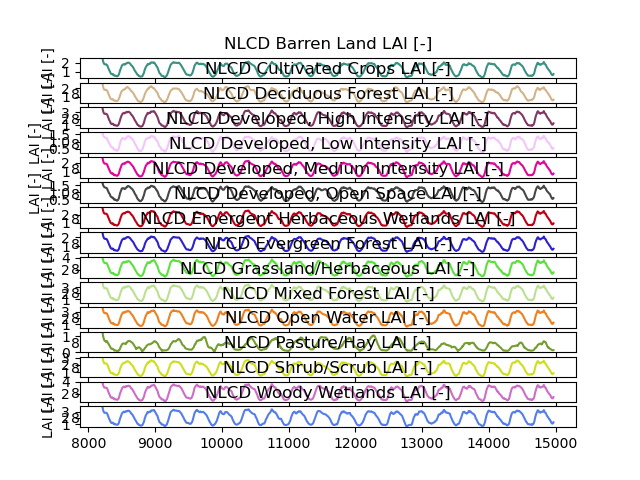

In [14]:
# smooth the data
df_smooth = pandas.DataFrame()
df_smooth['time [d]'] = df['time [d]']
for k in df.keys():
    if k != 'time [d]':
        df_smooth[k] = scipy.signal.savgol_filter(df[k], 101, 3)

        
# plot comparison
fig = plt.figure()
axs = fig.subplots(15,1)
#plot(df, '-', axs)
plot(df_smooth, '-', axs)
plt.show()

In [15]:
# add time back and write to disk
outputs['modis_filename'] = f'../data-processed/{name}_MODIS_LAI_smoothed_2002_2020.h5'

df_smooth['time [s]'] = df_smooth['time [d]']*86400
with h5py.File(outputs['modis_filename'],'w') as fid:
    for k in df_smooth:
        fid.create_dataset(k, data=df_smooth[k][:])

In [16]:
df = df_smooth

# split into n_years dataframes, one per year
df_yr = []
for year in range(23, 39):
    yr = df.loc[df_interp['time [d]'] >= year*365]
    df_yr.append(yr.loc[yr['time [d]'] < (year+1)*365])

# average across the years
df_avg = pandas.DataFrame()
for yr in df_yr:
    for k in yr.keys():
        if not k.startswith('time'):
            if k in df_avg:
                df_avg[k] = df_avg[k].array + yr[k].array
            else:
                df_avg[k] = yr[k].copy()

for k in df_avg.keys():
    df_avg[k] = df_avg[k][:] / len(df_yr)

df_avg['time [d]'] = df['time [d]']


In [17]:
# replicate 40 times to make 40 years (remem)
# tile all data to repeat n_year times
df_rep = pandas.DataFrame()
for key in df_avg:
    if not key.startswith('time'):
        df_rep[key] = np.tile(df_avg[key].array, 40)
        assert(len(df_rep) == 40*365)
    
# time is simply daily data
df_rep['time [s]'] = 86400. * np.arange(0., 40 * 365., 1.)
df_rep['time [d]'] = np.arange(0., 40 * 365., 1.)

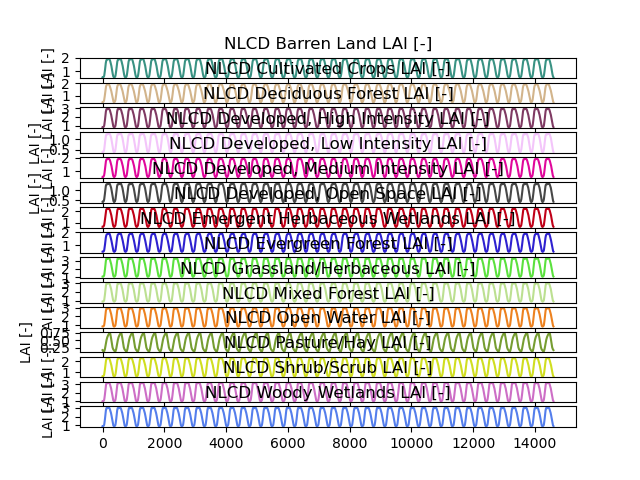

In [18]:
# plot this and make sure it looks right
fig = plt.figure()
axs = fig.subplots(15,1)
plot(df_rep, '-', axs)
plt.show()

In [19]:
# write to disk
outputs['modis_typical_filename'] = f'../data-processed/{name}_MODIS_LAI_typical_1980_2020.h5'

with h5py.File(outputs['modis_typical_filename'],'w') as fid:
    for k in df_rep:
        fid.create_dataset(k, data=df_rep[k][:])

## Write ATS input files

We now generate three input files -- two for spinup (steadystate solution and cyclic steadystate solution) and one for transient runs.

Steadystate has its own physics, but cyclic steadystate and transient share a common set of physics.  Each have their own met data strategy.

The first step is to generate the sections of xml that will replace parts of the template files.  This is done prior to loading any templates to make clear that these are totally generated from scratch using the ats_input_spec tool.

Note that throughout, we will assume an additional level of folder nesting, e.g. runs will be completed in '../spinup-CoalCreek/run0', meaning that we have to append an extra '../' to the start of all filenames.  This makes it easier to deal with mistakes, continued runs, etc.

In [20]:
# get an ATS "main" input spec list -- note, this is a dummy and is not used to write any files yet
main_list = ats_input_spec.public.get_main()


In [21]:
# Load manning values that was saved in NLCD_Manning_labels.to_csv(f'../data-processed/{name}_NLCD_Manning.csv')

NLCD_Manning_values = pandas.read_csv(f'../data-processed/{name}_NLCD_Manning.csv')
# Set the index as the first column 
NLCD_Manning_values.set_index(NLCD_Manning_values.columns[0], inplace=True)


In [22]:
# add the subsurface and surface domains
#
# Note this also adds a "computational domain" region to the region list, and a vis spec 
# for "domain"
mesh_filename = os.path.join('..', outputs['mesh_filename'])

ats_input_spec.public.add_domain(main_list, 
                                 domain_name='domain', 
                                 dimension=3, 
                                 mesh_type='read mesh file', 
                                 mesh_args={'file':mesh_filename})
main_list['mesh']['domain']['build columns from set'] = 'surface'

# Note this also adds a "surface domain" region to the region list and a vis spec for 
# "surface"
ats_input_spec.public.add_domain(main_list,
                                domain_name='surface',
                                dimension=2,
                                mesh_type='surface',
                                mesh_args={'surface sideset name':'surface'})

# Add the snow and canopy domains, which are aliases to the surface
ats_input_spec.public.add_domain(main_list,
                                domain_name='snow',
                                dimension=2,
                                mesh_type='aliased',
                                mesh_args={'target':'surface'})
ats_input_spec.public.add_domain(main_list,
                                domain_name='canopy',
                                dimension=2,
                                mesh_type='aliased',
                                mesh_args={'target':'surface'})

# add the "surface boundary" list
ats_input_spec.public.add_region(main_list,
                                region_name='surface boundary',
                                region_type='boundary',
                                region_args={'entity': 'FACE'})

# Add PK tree
ats_input_spec.public.add_leaf_pk(main_list, 'flow', main_list['cycle driver']['PK tree'], 
                                            'richards-spec')

def add_labeled_set(ls_name, label, entity_kind):
    """Helper function to add labeled sets to the main list"""
    ats_input_spec.public.add_region(main_list,
                                    region_name=ls_name,
                                    region_type='labeled set',
                                    region_args={'label' : str(label), 
                                                 'file' : mesh_filename,
                                                 'format' : 'Exodus II',
                                                 'entity' : entity_kind})

# add the bottom and surface sets
# add_labeled_set('bottom_face', 1, 'FACE')
# add_labeled_set('surface', 2, 'FACE')

# Add the labeled sets created in the mesh file (NLCD, soils, watersheds)
# add labeled sets
for ls in m3.labeled_sets:
    ats_input_spec.public.add_region_labeled_set(main_list, ls.name, ls.setid, mesh_filename, ls.entity)
for ss in m3.side_sets:
    ats_input_spec.public.add_region_labeled_set(main_list, ss.name, ss.setid, mesh_filename, 'FACE')

# # Option to do it by NLCD, and soilds
# # add the NLCD labeled sets
# for index, nlcd_name in zip(nlcd_indices, nlcd_labels):
#     add_labeled_set(nlcd_name, index, 'FACE')

# add soil sets: note we need a way to name the set, so we use, e.g. SSURGO-MUKEY.
def soil_set_name(ats_id):
    if ats_id == 999:
        return 'bedrock'
    source = subsurface_props.loc[ats_id]['source']
    native_id = subsurface_props.loc[ats_id]['native_index']
    if type(native_id) in [tuple,list]:
        native_id = native_id[0]
    return f"{source}-{native_id}"

for ats_id in subsurface_props.index:
    set_name = soil_set_name(ats_id)
    add_labeled_set(set_name, ats_id, 'CELL')


print(main_list)

cycle driver [coordinator-spec] : [incomplete]
  ONE OF:
    end time [double] : None
    end time units [string] : "s"
  OR:
    end cycle [int] : [optional]
  start time [double] : 0.00000000
  start time units [string] : "s"
  subcycled timestep [bool] : false
  restart from checkpoint file [string] : [optional]
  wallclock duration [hrs] [double] : [optional]
  required times [io-event-spec] : [optional]
    cycles start period stop [Array(int)] : [optional]
    cycles start period stop 0 [Array(int)] : [optional]
    cycles [Array(int)] : [optional]
    times start period stop [Array(double)] : [optional]
    times start period stop units [string] : s
    times start period stop 0 [Array(double)] : [optional]
    times start period stop 0 units [string] : s
    times [Array(double)] : [optional]
    times units [string] : s
  PK tree [pk-typed-spec-list] : [incomplete]
    flow [TypedCollection] : [incomplete]
      pk type [string] : richards-spec
      richards-spec parameters [

In [23]:
# native_id = subsurface_props.loc[100]['native_index']
# native_id
# # Check if native_id is tuple or list
# if type(native_id) in [tuple,list]:
#     print(native_id[0])
# else:
#     print('Check', native_id)

In [24]:
# next write a land-cover section for each NLCD type
land_cover_list = ats_input_spec.public.known_specs['land-cover-spec-list']
main_list['state']['initial conditions']['land cover types'] = land_cover_list

def add_land_cover_default(main, lc_name):
    """Adds a default land-cover type to the spec."""
    lc = main['state']['initial conditions']['land cover types'].append_empty(lc_name)
    # print(lc)
    # set some basic defaults
    lc['Priestley-Taylor alpha of snow [-]'] = 1.26 # 1.8
    lc['Priestley-Taylor alpha of bare ground [-]'] = 1.26 # 1.8
    lc['Priestley-Taylor alpha of canopy [-]'] = 1.26 # 1.8
    lc['Priestley-Taylor alpha of transpiration [-]'] = 1.26 # 1.8

    lc['albedo of bare ground [-]'] = 0.4
    lc['emissivity of bare ground [-]'] = 0.98
    lc['albedo of canopy [-]'] = 0.11
    # lc['emissivity of canopy [-]'] = 0.95
    
    lc["Beer's law extinction coefficient, shortwave [-]"] = 0.6
    lc["Beer's law extinction coefficient, longwave [-]"] = 5
    
    lc["snow transition depth [m]"] = 0.02
    lc["dessicated zone thickness [m]"] = 0.005 # Based on https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2008JD010834
    lc["Clapp and Hornberger b [-]"] = 3 # Based on the median value obatined in the b histogram using code vg2bc_example.ipynb
    
    # defaults for grass/no vei
    lc['rooting depth max [m]'] = 5.
    lc['rooting profile alpha [-]'] = 11.0
    lc['rooting profile beta [-]'] = 2.0
    
    
    # Note, the mafic potential values are likely pretty bad for the types of van Genuchten 
    # curves we are using (https://www.sciencedirect.com/science/article/pii/S0168192314000483).
    # Likely they need to be modified.  Note that these values are in [mm] from CLM TN 4.5 table 8.1, so the 
    # factor of 10 converts to [Pa].

    lc['mafic potential at fully closed stomata [Pa]'] = 2750000.
    lc['mafic potential at fully open stomata [Pa]'] = 740000
    
    # by default we let the LAI take care of this rather than turn off deciduous 
    # transpiration manually the way that PRMS does it. 
    lc['leaf on time [doy]'] = -1
    lc['leaf off time [doy]'] = -1
    return lc

# add default lists for all types
for index, nlcd_name in zip(nlcd_indices, nlcd_labels):
    # print(index, nlcd_name)
    lc = add_land_cover_default(main_list, nlcd_name)

# update some defaults
# ['Other', 'Deciduous Forest', 'Evergreen Forest', 'Shrub/Scrub']
# note, these are from the CLM Technical Note v4.5
#
# Rooting depth curves from CLM TN 4.5 table 8.3
#
# Note, the mafic potential values are likely pretty bad for the types of van Genuchten 
# curves we are using (ETC -- add paper citation about this topic).  Likely they need
# to be modified.  Note that these values are in [mm] from CLM TN 4.5 table 8.1, so the 
# factor of 10 converts to [Pa]
#
# Note, albedo of canopy taken from CLM TN 4.5 table 3.1
    
# ADD Here each land cover manually
land_cover_list['Evergreen Forest']['rooting profile alpha [-]'] = 7.0
land_cover_list['Evergreen Forest']['rooting profile beta [-]'] = 2.0
land_cover_list['Evergreen Forest']['rooting depth max [m]'] = 10.0
land_cover_list['Evergreen Forest']['mafic potential at fully closed stomata [Pa]'] = 2550000
land_cover_list['Evergreen Forest']['mafic potential at fully open stomata [Pa]'] = 660000
land_cover_list['Evergreen Forest']['albedo of canopy [-]'] = 0.07

land_cover_list['Deciduous Forest']['rooting profile alpha [-]'] = 6.0
land_cover_list['Deciduous Forest']['rooting profile beta [-]'] = 2.0
land_cover_list['Deciduous Forest']['rooting depth max [m]'] = 10.0
land_cover_list['Deciduous Forest']['mafic potential at fully closed stomata [Pa]'] = 2240000
land_cover_list['Deciduous Forest']['mafic potential at fully open stomata [Pa]'] = 350000
land_cover_list['Deciduous Forest']['albedo of canopy [-]'] = 0.1


In [25]:
# Add the surface-leaf_area_index for each land cover type
known_specs = ats_input_spec.public.known_specs
elist = main_list['state']['evaluators']
lai = elist.append_empty('canopy-leaf_area_index') # ('surface-leaf_area_index')
lai.set_type('independent variable', known_specs['independent-variable-function-evaluator-spec'])
 
for lc in nlcd_labels: # insert your lc names here...
    sublist = lai['function'].append_empty(lc)
    sublist['region'] = lc
    sublist['component'] = 'cell'
    entry = sublist['function'].set_type('tabular', known_specs['function-tabular-fromfile-spec'])
    entry['file'] = outputs['modis_typical_filename'] 
    entry['x header'] = 'time [s]' # probably this is your time header?  Could be different...
    # Check if the lc is an Open Channels, this is done by checking if the labels starts by Open
    if lc.startswith('Open'):
        entry['y header'] = 'NLCD Open Water LAI [-]' 
    else:
        entry['y header'] = f'NLCD {lc} LAI [-]' # note, this is whatever the name of the lai data in the h5 file is

In [26]:
# finally, we write soil property specs for porosity, permeability, and WRMs
poro_eval = main_list['state']['evaluators'].append_empty('base_porosity')
# poro_eval = main_list['state']['field evaluators'].append_empty('base_porosity')
poro_eval.set_type('independent variable', ats_input_spec.public.known_specs['independent-variable-function-evaluator-spec'])
# poro_eval.set_type('independent variable', ats_input_spec.public.known_specs['independent-variable-evaluator-spec'])
poro_eval['constant in time'] = True

perm_eval = main_list['state']['evaluators'].append_empty('permeability')
# perm_eval = main_list['state']['field evaluators'].append_empty('permeability')
perm_eval.set_type('independent variable', ats_input_spec.public.known_specs['independent-variable-function-evaluator-spec'])
# perm_eval.set_type('independent variable', ats_input_spec.public.known_specs['independent-variable-evaluator-spec'])
perm_eval['constant in time'] = True

wrm_eval = main_list['state']['evaluators'].append_empty('saturation_liquid')
# wrm_eval = main_list['state']['field evaluators'].append_empty('saturation_liquid')
wrm_eval.set_type('WRM rel perm', ats_input_spec.public.known_specs['rel-perm-evaluator-spec'])
wrm_eval['boundary rel perm strategy'] = 'surface rel perm'
wrm_eval['permeability rescaling'] = 1e7

# Add mannings n for each land cover type
manning_eval = main_list['state']['evaluators'].append_empty('surface-manning_coefficient')
# manning_eval = main_list['state']['field evaluators'].append_empty('surface-manning_coefficient')
manning_eval.set_type('independent variable constant', ats_input_spec.public.known_specs['independent-variable-function-evaluator-spec'])
manning_eval['constant in time'] = True

print(main_list['state']['evaluators'])
# print(main_list['state']['field evaluators'])

canopy-leaf_area_index [TypedCollection] : [complete]
  evaluator type [string] : independent variable
  constant in time [bool] : false
  function [composite-vector-function-spec-list] : [complete]
    Open Water [TypedCollection] : [complete]
      region [string] : Open Water
      component [string] : cell
      function [function-typedinline-spec] : [complete]
        function type [string] : tabular
        file [string] : ../data-processed/neches_MODIS_LAI_typical_1980_2020.h5
        x header [string] : time [s]
        y header [string] : NLCD Open Water LAI [-]
        forms [string] : [optional]
    Developed, Open Space [TypedCollection] : [complete]
      region [string] : Developed, Open Space
      component [string] : cell
      function [function-typedinline-spec] : [complete]
        function type [string] : tabular
        file [string] : ../data-processed/neches_MODIS_LAI_typical_1980_2020.h5
        x header [string] : time [s]
        y header [string] : NLCD Deve

In [27]:
def add_region_set_value(evaluator, ats_id, val):
    region = soil_set_name(ats_id)
    my_func = evaluator['function'].append_empty(region)
    my_func['region'] = region
    my_func['component'] = 'cell'
    my_func_const = my_func['function'].set_type('constant', 
                                                 ats_input_spec.public.known_specs['function-constant-spec'])
    my_func_const['value'] = float(val)

def add_wrm(evaluator, ats_id, props):
    region = soil_set_name(ats_id)
    wrm = wrm_eval['WRM parameters'].append_empty(region)
    wrm.set_type('van Genuchten', ats_input_spec.public.known_specs['WRM-van-Genuchten-spec'])

    wrm['region'] = region
    wrm['van Genuchten alpha [Pa^-1]'] = float(props['van Genuchten alpha [Pa^-1]'])
    wrm['van Genuchten n [-]'] = float(props['van Genuchten n [-]'])
    wrm['residual saturation [-]'] = float(props['residual saturation [-]'])
    if wrm['van Genuchten n [-]'] < 1.5:
        wrm['smoothing interval width [saturation]'] = 0.01
    else:
        wrm['smoothing interval width [saturation]'] = 0.0
    
for ats_id in subsurface_props.index:
    add_region_set_value(poro_eval, ats_id, subsurface_props.loc[ats_id]['porosity [-]'])
    add_region_set_value(perm_eval, ats_id, subsurface_props.loc[ats_id]['permeability [m^2]'])
    add_wrm(wrm_eval, ats_id, subsurface_props.loc[ats_id])

# Add mannings n for each soil type
def add_region_set_value_manning(evaluator, region, val):
    my_func = evaluator['function'].append_empty(region)
    my_func['region'] = region
    my_func['component'] = 'cell'
    my_func_const = my_func['function'].set_type('constant', 
                                                 ats_input_spec.public.known_specs['function-constant-spec'])
    my_func_const['value'] = float(val)

for region in nlcd_labels:
    add_region_set_value_manning(manning_eval, region, NLCD_Manning_values.loc[region]['Manning value'])

print(main_list['state']['evaluators'])
# print(main_list['state']['field evaluators'])

canopy-leaf_area_index [TypedCollection] : [complete]
  evaluator type [string] : independent variable
  constant in time [bool] : false
  function [composite-vector-function-spec-list] : [complete]
    Open Water [TypedCollection] : [complete]
      region [string] : Open Water
      component [string] : cell
      function [function-typedinline-spec] : [complete]
        function type [string] : tabular
        file [string] : ../data-processed/neches_MODIS_LAI_typical_1980_2020.h5
        x header [string] : time [s]
        y header [string] : NLCD Open Water LAI [-]
        forms [string] : [optional]
    Developed, Open Space [TypedCollection] : [complete]
      region [string] : Developed, Open Space
      component [string] : cell
      function [function-typedinline-spec] : [complete]
        function type [string] : tabular
        file [string] : ../data-processed/neches_MODIS_LAI_typical_1980_2020.h5
        x header [string] : time [s]
        y header [string] : NLCD Deve

In [28]:
# Add observations to the main list
# add observations for each subcatchment for transient runs
ats_input_spec.public.add_observations_water_balance(main_list, "computational domain", 
                                                        "surface domain","external_sides")

for poly in watershed.polygons():
    region = poly.properties['name']
    ats_input_spec.public.add_observations_water_balance(main_list, region, outlet_region=region+' outlet')

In [29]:
outputs['generated_ats'] = f'../data-processed/{name}_generated_ats.xml'
ats_input_spec.io.write(main_list, outputs['generated_ats'])
main_xml = ats_input_spec.io.to_xml(main_list)

/Users/gpq/ORNL/Projects/SETx_Urban/ATS_Implementation/ats_input_spec/ats_input_spec/io.py:43: UserWarning: Creating an incomplete XML object, missing entries!
  warnings.warn('Creating an incomplete XML object, missing entries!')


In [30]:
# Use {name}_generated_ats.xml to mannually create the templates xml files for the steady state, cyclic, and transient xml files.

In [31]:
def populate_basic_properties(xml, homogeneous_wrm=False, homogeneous_poro=False, homogeneous_perm=False, homogeneous_manning=False):
    """This function updates an xml object with the above properties for mesh, regions, soil props, and lc props"""
    # find and replace the mesh list
    mesh_i = next(i for (i,el) in enumerate(xml) if el.get('name') == 'mesh')
    xml[mesh_i] = asearch.child_by_name(main_xml, 'mesh')

    # find and replace the regions list
    region_i = next(i for (i,el) in enumerate(xml) if el.get('name') == 'regions')
    xml[region_i] = asearch.child_by_name(main_xml, 'regions')

    # find and replace the WRMs list -- note here we only replace the inner "WRM parameters" because the
    # demo has this in the PK, not in the field evaluators list
    if not homogeneous_wrm:
        wrm_list = asearch.find_path(xml, ['PKs', 'water retention evaluator'])
        wrm_i = next(i for (i,el) in enumerate(wrm_list) if el.get('name') == 'WRM parameters')
        wrm_list[wrm_i] = asearch.find_path(main_xml, ['state','evaluators','WRM parameters'])
        # wrm_list[wrm_i] = asearch.find_path(main_xml, ['state','field evaluators','WRM parameters'])

    fe_list = asearch.find_path(xml, ['state', 'evaluators'])
    # fe_list = asearch.find_path(xml, ['state', 'field evaluators'])

    # find and replace porosity, permeability
    if not homogeneous_poro:
        poro_i = next(i for (i,el) in enumerate(fe_list) if el.get('name') == 'base_porosity')
        fe_list[poro_i] = asearch.find_path(main_xml, ['state', 'evaluators', 'base_porosity'])
        # fe_list[poro_i] = asearch.find_path(main_xml, ['state', 'field evaluators', 'base_porosity'])

    if not homogeneous_perm:
        perm_i = next(i for (i,el) in enumerate(fe_list) if el.get('name') == 'permeability')
        fe_list[perm_i] = asearch.find_path(main_xml, ['state', 'evaluators', 'permeability'])
        # fe_list[perm_i] = asearch.find_path(main_xml, ['state', 'field evaluators', 'permeability'])

    if not homogeneous_manning:
        mann_i = next(i for (i,el) in enumerate(fe_list) if el.get('name') == 'surface-manning_coefficient')
        fe_list[mann_i] = asearch.find_path(main_xml, ['state', 'evaluators', 'surface-manning_coefficient'])
        # fe_list[mann_i] = asearch.find_path(main_xml, ['state', 'field evaluators', 'surface-manning_coefficient'])

    # find and replace land cover
    consts_list = asearch.find_path(xml, ['state', 'initial conditions'])
    try:
        lc_i = next(i for (i,el) in enumerate(consts_list) if el.get('name') == 'land cover types')
    except StopIteration:
        pass
    else:
        consts_list[lc_i] = asearch.find_path(main_xml, ['state', 'initial conditions', 'land cover types'])

def create_unique_name(name, homogeneous_wrm=False, homogeneous_poro=False, homogeneous_perm=False, homogeneous_manning=False):
    suffix = '_h'
    if homogeneous_manning:
        suffix += 'm'
    if homogeneous_perm:
        suffix += 'K'
    if homogeneous_poro:
        suffix += 'p'
    if homogeneous_wrm:
        suffix += 'w'
    if suffix == '_h':
        suffix = ''
    return name + suffix
        

For the first file, we load a spinup template and write the needed quantities into that file, saving it to the appropriate run directory.  Note there is no DayMet or land cover or LAI properties needed for this run.  The only property that is needed is the domain-averaged, mean annual rainfall rate.  We then take off some for ET (note too wet spins up faster than too dry, so don't take off too much...).

In [32]:
# calculate the basin-averaged, annual-averaged precip rate
# precip_total = ats_typ['precipitation rain [m s^-1]'] + ats_typ['precipitation snow [m SWE s^-1]']
# mean_precip = precip_total.mean()

mean_precip = 4.7832247470470154e-08
logging.info(f'Mean annual precip rate [m s^-1] = {mean_precip}')

2024-05-03 11:29:04,773 - root - INFO: Mean annual precip rate [m s^-1] = 4.7832247470470154e-08


In [33]:
def write_spinup_steadystate(name, **kwargs):
    name = create_unique_name(name, **kwargs)
    logging.info(f'Writing transient: {name}')
    
    # write the spinup xml file
    # load the template file
    xml = aio.fromFile('spinup_steadystate-template.xml')

    # populate basic properties for mesh, regions, and soil properties
    populate_basic_properties(xml, **kwargs)


    # set the mean avg source as 60% of mean precip
    precip_el = asearch.find_path(xml, ['state', 'evaluators', 'surface-precipitation', 
                                        'function-constant', 'value'])
    # precip_el = asearch.find_path(xml, ['state', 'field evaluators', 'surface-precipitation', 
                                        # 'function-constant', 'value'])
    precip_el.setValue(mean_precip * .6)


    # write to disk
    outputs[f'spinup_steadystate_{name}_filename'] = f'../run0-spinup_steadystate/{name}.xml'
    aio.toFile(xml, outputs[f'spinup_steadystate_{name}_filename'])

    # make a run directory
    outputs[f'spinup_steadystate_{name}_rundir'] = f'../run0-spinup_steadystate/{name}-0'
    try:
        os.mkdir(outputs[f'spinup_steadystate_{name}_rundir'])
    except FileExistsError:
        pass

For the second file, we load a transient run template.  This file needs the basics, plus DayMet and LAI as the "typical year data".  Also we set the run directory that will be used for the steadystate run.

For the third file, we load a transient run template as well.  This file needs the basics, DayMet with the actual data, and we choose for this run to use the MODIS typical year.  MODIS is only available for 2002 on, so if we didn't need 1980-2002 we could use the real data, but for this run we want a longer record.

In [34]:
def write_transient(name, cyclic_steadystate=False, start_year=1980, end_year=2020, **kwargs):
    # make a unique name based on options
    name = create_unique_name(name, **kwargs)
    logging.info(f'Writing transient: {name}')

    if cyclic_steadystate:
        prefix = 'spinup_cyclic'
        start_year = 1980
        end_year = 1990
        previous = 'spinup_steadystate'
        runnum = 'run1'
    else:
        prefix = 'transient'
        previous = 'spinup_cyclic'
        runnum = 'run2'

    template_filename = f'{prefix}-template.xml'
    
    # write the cyclic spinup xml file
    # load the template file
    xml = aio.fromFile(template_filename)

    # populate basic properties for mesh, regions, and soil properties
    populate_basic_properties(xml, **kwargs)

    # update the DayMet filenames
    if cyclic_steadystate:
        daymet_filename = outputs['daymet_spinup_filename']
    else:
        daymet_filename = outputs['daymet_filename']
    for var in ['surface-incoming_shortwave_radiation',
                'surface-precipitation_rain',
                'snow-precipitation',
                'surface-air_temperature',
                'surface-relative_humidity',
                'surface-temperature',
                'canopy-temperature']:
        try:
            par = asearch.find_path(xml, ['state', 'evaluators', var, 'file'])
        except aerrors.MissingXMLError:
            pass
        else:
            par.setValue(os.path.join('..', daymet_filename))

    # update the LAI filenames
    for par in asearch.findall_path(xml, ['canopy-leaf_area_index', 'file']):
        par.setValue(os.path.join('..', outputs['modis_typical_filename']))
    
    # update the start and end time -- start at Oct 1 of year 0, end 10 years later
    start_day = 274 + 365*(start_year - 1980)
    par = asearch.find_path(xml, ['cycle driver', 'start time'])
    par.setValue(start_day)

    end_day = 274 + 365*(end_year - 1980)
    par = asearch.find_path(xml, ['cycle driver', 'end time'])
    par.setValue(end_day)
    
    # update the restart filenames
    for var in asearch.findall_path(xml, ['initial condition', 'restart file']):
        var.setValue(os.path.join('..', outputs[f'{previous}_{name}_rundir'], 'checkpoint_final.h5'))

    # # Remove unwanted output variables
    # variables_remove = ['runon only [mol d^-1]', 'runoff only [mol d^-1]', 'river discharge [mol d^-1]', 'net groundwater flux [mol d^-1]', 'infiltration [mol d^-1]']
    # for label in variables_remove:
    #     asearch.remove_element(xml, ['observed quantities',label])

    # write to disk and make a directory for running the run
    outputs[f'{prefix}_{name}_filename'] = f'../{runnum}-{prefix}/{name}.xml'
    filename = outputs[f'{prefix}_{name}_filename']

    outputs[f'{prefix}_{name}_rundir'] = f'../{runnum}-{prefix}/{name}-0'
    rundir = outputs[f'{prefix}_{name}_rundir']

    # # set the LAI time series for each NLCD class. We use the following mapping: This translation need to be done manually on the xml file!
    # # NLCD Evergreen forest LAI [-] --> ['Evergreen Forest', 'Deciduous Forest','Dwarf Scrub', 'Shrub/Scrub', 'Grassland/Herbaceous', 'Sedge/Herbaceous', 
    # #                      'Pasture/Hay', 'Cultivated Crops']
    # # NLCD Deciduous forest LAI [-] --> ['Mixed Forest', 'Woody Wetlands','Emergent Herbaceous Wetlands']
    # # NLCD Developed LAI [-] --> ['Developed, Open Space', 'Developed, Low Intensity', 'Developed, Medium Intensity', 'Developed, High Intensity',]
    # # 0 --> ['Open Water', 'Perennial Ice/Snow','Barren Land',  'Lichens', 'Moss'] 
    # # 0 --> All the Open Channel classes
    # # Note that these mapping is based on the correlation found during the function "watershed_workflow.land_cover_properties.compute_crosswalk_correlation"
    
    # nlcd_labels_ref = ['Evergreen Forest', 'Deciduous Forest', 'Mixed Forest', 'Dwarf Scrub', 'Shrub/Scrub', 'Grassland/Herbaceous',
    #                     'Sedge/Herbaceous', 'Woody Wetlands', 'Pasture/Hay', 'Cultivated Crops', 'Open Water', 'Perennial Ice/Snow',
    #                       'Developed, Open Space', 'Developed, Low Intensity', 'Developed, Medium Intensity', 'Developed, High Intensity',
    #                         'Barren Land', 'Emergent Herbaceous Wetlands', 'Lichens', 'Moss', 'Open Channel 1', 'Open Channel 2',
    #                         'Open Channel 3', 'Open Channel 4', 'Open Channel 5', 'Open Channel 6', 'Open Channel 7',
    #                         'Open Channel 8', 'Open Channel 9', 'Open Channel 10']
    # # The template (steady, cyclic, and transient) has all the NLCD classes and 10 Open Channel classes. We need to remove the ones that are not used.
    # nlcd_labels_remove = [x for x in nlcd_labels_ref if x not in nlcd_labels]
    # for label in nlcd_labels_remove:
    #     asearch.remove_element(xml, ['canopy-leaf_area_index',label])

    aio.toFile(xml, filename)
    try:
        os.mkdir(rundir)
    except FileExistsError:
        pass

In [35]:
# nlcd_labels_ref = ['Evergreen Forest', 'Deciduous Forest', 'Mixed Forest', 'Dwarf Scrub', 'Shrub/Scrub', 'Grassland/Herbaceous',
#                         'Sedge/Herbaceous', 'Woody Wetlands', 'Pasture/Hay', 'Cultivated Crops', 'Open Water', 'Perennial Ice/Snow',
#                           'Developed, Open Space', 'Developed, Low Intensity', 'Developed, Medium Intensity', 'Developed, High Intensity',
#                             'Barren Land', 'Emergent Herbaceous Wetlands', 'Lichens', 'Moss', 'Open Channel 1', 'Open Channel 2',
#                             'Open Channel 3', 'Open Channel 4', 'Open Channel 5', 'Open Channel 6', 'Open Channel 7',
#                             'Open Channel 8', 'Open Channel 9', 'Open Channel 10']
#     # The template (steady, cyclic, and transient) has all the NLCD classes and 10 Open Channel classes. We need to remove the ones that are not used.
# nlcd_labels_remove = [x for x in nlcd_labels_ref if x not in nlcd_labels]
# nlcd_labels_remove

In [36]:
# create the fully-heterogeneous runs
if include_heterogeneous:
    write_spinup_steadystate(name)
    write_transient(name, True)
    write_transient(name, False)

2024-05-03 11:29:04,874 - root - INFO: Writing transient: neches
2024-05-03 11:29:05,013 - root - INFO: Writing transient: neches
2024-05-03 11:29:05,224 - root - INFO: Writing transient: neches


In [37]:
# Change some names for compatibility with ATS 1.3 and parameters for perlmutter hpc

for prefix in ['spinup_steadystate', 'spinup_cyclic', 'transient']:
    with open(outputs[f'{prefix}_{name}_filename'], 'r') as file:
        content = file.read()

    new_content = content.replace('"evaluators"', '"field evaluators"')
    new_content = new_content.replace('"evaluator type"', '"field evaluator type"')
    new_content = new_content.replace('<Parameter name="wallclock duration [hrs]" type="double" value="23.9" />', '<Parameter name="wallclock duration [hrs]" type="double" value="11.9" />')

    if prefix == 'spinup_steadystate':
        new_content = new_content.replace('<Parameter name="end cycle" type="int" value="100000" />', '<Parameter name="end cycle" type="int" value="10000" />')
        new_content = new_content.replace('<Parameter name="hydrostatic head [m]" type="double" value="-1" />', '<Parameter name="hydrostatic head [m]" type="double" value="-0.5" />')

    with open(outputs[f'{prefix}_{name}_filename'], 'w') as file:
        file.write(new_content)

# Final notes:
# The transpiration coefficients for each land cover type are taken from Bhanja, S. et al 2023 - Supplemenatal Material 
# If StageIV date is used (hourly rainfall),the rainfall input path on the run2 file must point to the StageIV hourly rainfall file
# Check the max time step size and initial time step size for each run.
# For daymet 
#   <Parameter name="max time step size [s]" type="double" value="86400" />
#   <Parameter name="initial time step" type="double" value="8640" />
# For StageIV 
#   <Parameter name="max time step size [s]" type="double" value="3600" />
#   <Parameter name="initial time step" type="double" value="360" />

# Change the output headers and time units for the observations from d to h. 

# Set the right rainfall inputs for run2!

# If the error "bad_flux" is encountered, the system  forces evaporation despite trere is not available water in the soil. 
# This can be solved by neglicting transpiration by using:
#   <Parameter name="mafic potential at fully closed stomata [Pa]" type="double" value="25500" />
#   <Parameter name="mafic potential at fully open stomata [Pa]" type="double" value="3500" />

# Check the restart files for each run!

# The LAI time series for each NLCD class need to be set manually, depending on correlation found during the function "watershed_workflow.land_cover_properties.compute_crosswalk_correlation"
        

# Initial simulations are conducted using a nonlinear tolerance of 1e-4 for testing. This should be 1e-6

In [38]:
# Convert xml format from 1.3 to 1.4 version
ats_src_dir = os.getenv('ATS_SRC_DIR')
# Construct the full path to the converter script
path_convert_1_3_to_1_4 = os.path.join(ats_src_dir, 'tools', 'input_converters', 'xml-1.3-1.4.py')

# Specify the path to the XML file to convert
xml_file_path = '../run0-spinup_steadystate/neches.xml'
command = ['python', path_convert_1_3_to_1_4, '-i', xml_file_path]
result = subprocess.run(command, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

xml_file_path = '../run1-spinup_cyclic/neches.xml'
command = ['python', path_convert_1_3_to_1_4, '-i', xml_file_path]
result = subprocess.run(command, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

xml_file_path = '../run2-transient/neches.xml'
command = ['python', path_convert_1_3_to_1_4, '-i', xml_file_path]
result = subprocess.run(command, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)


In [39]:
# Convert xml format from 1.4 to master

# Construct the full path to the converter script
path_convert_1_4_to_master = os.path.join(ats_src_dir, 'tools', 'input_converters', 'xml-1.4-master.py')

# Specify the path to the XML file to convert
xml_file_path = '../run0-spinup_steadystate/neches.xml'
command = ['python', path_convert_1_4_to_master, '-i', xml_file_path]
result = subprocess.run(command, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

xml_file_path = '../run1-spinup_cyclic/neches.xml'
command = ['python', path_convert_1_4_to_master, '-i', xml_file_path]
result = subprocess.run(command, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

xml_file_path = '../run2-transient/neches.xml'
command = ['python', path_convert_1_4_to_master, '-i', xml_file_path]
result = subprocess.run(command, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)


In [40]:
# Testing runs
# steaady state 
# (5 years)
    # <ParameterList name="cycle driver">
    # <Parameter name="start time" type="double" value=" 0" />
    # <Parameter name="start time units" type="string" value="s" />
    # <Parameter name="end time" type="double" value="2000" />

# nonlinear tolerance 1e-04
# <Parameter name="nonlinear tolerance" type="double" value="1e-04" />